In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os

os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
print("folders ready")

folders ready


In [3]:
import urllib.request

url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE72nnn/GSE72056/suppl/GSE72056_melanoma_single_cell_revised_v2.txt.gz"
out = "data/raw/GSE72056_melanoma_single_cell_revised_v2.txt.gz"

urllib.request.urlretrieve(url, out)
print("downloaded:", out)

downloaded: data/raw/GSE72056_melanoma_single_cell_revised_v2.txt.gz


In [4]:
import pandas as pd

preview = pd.read_csv(
    "data/raw/GSE72056_melanoma_single_cell_revised_v2.txt.gz",
    sep="\t",
    nrows=5
)

preview


,Cell,Cy72_CD45_H02_S758_comb,CY58_1_CD45_B02_S974_comb,Cy71_CD45_D08_S524_comb,Cy81_FNA_CD45_B01_S301_comb,Cy80_II_CD45_B07_S883_comb,Cy81_Bulk_CD45_B10_S118_comb,Cy72_CD45_D09_S717_comb,Cy74_CD45_A03_S387_comb,Cy71_CD45_B05_S497_comb,...,CY75_1_CD45_CD8_7__S265_comb,CY75_1_CD45_CD8_3__S127_comb,CY75_1_CD45_CD8_1__S61_comb,CY75_1_CD45_CD8_1__S12_comb,CY75_1_CD45_CD8_1__S25_comb,CY75_1_CD45_CD8_7__S223_comb,CY75_1_CD45_CD8_1__S65_comb,CY75_1_CD45_CD8_1__S93_comb,CY75_1_CD45_CD8_1__S76_comb,CY75_1_CD45_CD8_7__S274_comb
0,tumor,72.0000,58.0000,71.000,81.0000,80.0000,81.0000,72.0000,74.0000,71.0000,...,75,75.0000,75.0000,75.00000,75.0000,75.0000,75.0000,75.0000,75.000,75.0000
1,"malignant(1=no,2=yes,0=unresolved)",1.0000,1.0000,2.000,2.0000,2.0000,2.0000,1.0000,1.0000,2.0000,...,1,1.0000,1.0000,1.00000,1.0000,1.0000,1.0000,1.0000,1.000,1.0000
2,"non-malignant cell type (1=T,2=B,3=Macro.4=End...",2.0000,1.0000,0.000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,...,1,1.0000,1.0000,1.00000,1.0000,1.0000,1.0000,1.0000,1.000,0.0000
3,C9orf152,0.0000,0.0000,0.000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0,0.0000,0.0000,0.00000,0.0000,0.0000,0.0000,0.0000,0.000,0.0000
4,RPS11,9.2172,8.3745,9.313,7.8876,8.3291,7.8336,8.3737,8.1338,8.4373,...,0,7.8639,5.8505,0.62639,6.2734,5.4889,4.9262,7.0958,3.997,3.9897


In [5]:
preview.columns[:10]

Index(['Cell', 'Cy72_CD45_H02_S758_comb', 'CY58_1_CD45_B02_S974_comb',
       'Cy71_CD45_D08_S524_comb', 'Cy81_FNA_CD45_B01_S301_comb',
       'Cy80_II_CD45_B07_S883_comb', 'Cy81_Bulk_CD45_B10_S118_comb',
       'Cy72_CD45_D09_S717_comb', 'Cy74_CD45_A03_S387_comb',
       'Cy71_CD45_B05_S497_comb'],
      dtype='object')

In [6]:
preview.iloc[:5, :5]

,Cell,Cy72_CD45_H02_S758_comb,CY58_1_CD45_B02_S974_comb,Cy71_CD45_D08_S524_comb,Cy81_FNA_CD45_B01_S301_comb
0,tumor,72.0000,58.0000,71.000,81.0000
1,"malignant(1=no,2=yes,0=unresolved)",1.0000,1.0000,2.000,2.0000
2,"non-malignant cell type (1=T,2=B,3=Macro.4=End...",2.0000,1.0000,0.000,0.0000
3,C9orf152,0.0000,0.0000,0.000,0.0000
4,RPS11,9.2172,8.3745,9.313,7.8876


In [7]:
preview

,Cell,Cy72_CD45_H02_S758_comb,CY58_1_CD45_B02_S974_comb,Cy71_CD45_D08_S524_comb,Cy81_FNA_CD45_B01_S301_comb,Cy80_II_CD45_B07_S883_comb,Cy81_Bulk_CD45_B10_S118_comb,Cy72_CD45_D09_S717_comb,Cy74_CD45_A03_S387_comb,Cy71_CD45_B05_S497_comb,...,CY75_1_CD45_CD8_7__S265_comb,CY75_1_CD45_CD8_3__S127_comb,CY75_1_CD45_CD8_1__S61_comb,CY75_1_CD45_CD8_1__S12_comb,CY75_1_CD45_CD8_1__S25_comb,CY75_1_CD45_CD8_7__S223_comb,CY75_1_CD45_CD8_1__S65_comb,CY75_1_CD45_CD8_1__S93_comb,CY75_1_CD45_CD8_1__S76_comb,CY75_1_CD45_CD8_7__S274_comb
0,tumor,72.0000,58.0000,71.000,81.0000,80.0000,81.0000,72.0000,74.0000,71.0000,...,75,75.0000,75.0000,75.00000,75.0000,75.0000,75.0000,75.0000,75.000,75.0000
1,"malignant(1=no,2=yes,0=unresolved)",1.0000,1.0000,2.000,2.0000,2.0000,2.0000,1.0000,1.0000,2.0000,...,1,1.0000,1.0000,1.00000,1.0000,1.0000,1.0000,1.0000,1.000,1.0000
2,"non-malignant cell type (1=T,2=B,3=Macro.4=End...",2.0000,1.0000,0.000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,...,1,1.0000,1.0000,1.00000,1.0000,1.0000,1.0000,1.0000,1.000,0.0000
3,C9orf152,0.0000,0.0000,0.000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0,0.0000,0.0000,0.00000,0.0000,0.0000,0.0000,0.0000,0.000,0.0000
4,RPS11,9.2172,8.3745,9.313,7.8876,8.3291,7.8336,8.3737,8.1338,8.4373,...,0,7.8639,5.8505,0.62639,6.2734,5.4889,4.9262,7.0958,3.997,3.9897


In [8]:
preview.columns[:10]

Index(['Cell', 'Cy72_CD45_H02_S758_comb', 'CY58_1_CD45_B02_S974_comb',
       'Cy71_CD45_D08_S524_comb', 'Cy81_FNA_CD45_B01_S301_comb',
       'Cy80_II_CD45_B07_S883_comb', 'Cy81_Bulk_CD45_B10_S118_comb',
       'Cy72_CD45_D09_S717_comb', 'Cy74_CD45_A03_S387_comb',
       'Cy71_CD45_B05_S497_comb'],
      dtype='object')

In [9]:
import pandas as pd
import scanpy as sc
import numpy as np

# load full table
df = pd.read_csv(
    "data/raw/GSE72056_melanoma_single_cell_revised_v2.txt.gz",
    sep="\t"
)

# metadata rows
meta = df.iloc[:3, :].copy()

# gene rows
expr = df.iloc[3:, :].copy()

# gene names
genes = expr["Cell"].astype(str).values

# cell names
cells = df.columns[1:]

# numeric matrix
X = expr.iloc[:, 1:].astype(float).T.values

# create AnnData
adata = sc.AnnData(X=X)

adata.obs_names = cells
adata.var_names = genes

# add metadata
adata.obs["sample_type"] = meta.iloc[0, 1:].values
adata.obs["malignant"] = meta.iloc[1, 1:].values
adata.obs["celltype_code"] = meta.iloc[2, 1:].values

adata

AnnData object with n_obs × n_vars = 4645 × 23686
    obs: 'sample_type', 'malignant', 'celltype_code'

In [10]:
adata.obs.head()


,sample_type,malignant,celltype_code
Cy72_CD45_H02_S758_comb,72.0,1.0,2.0
CY58_1_CD45_B02_S974_comb,58.0,1.0,1.0
Cy71_CD45_D08_S524_comb,71.0,2.0,0.0
Cy81_FNA_CD45_B01_S301_comb,81.0,2.0,0.0
Cy80_II_CD45_B07_S883_comb,80.0,2.0,0.0


In [11]:
adata.obs = adata.obs.rename(columns={
    "sample_type": "patient_id",
    "malignant": "malignant_code",
    "celltype_code": "celltype_code"
})

adata.obs.head()

,patient_id,malignant_code,celltype_code
Cy72_CD45_H02_S758_comb,72.0,1.0,2.0
CY58_1_CD45_B02_S974_comb,58.0,1.0,1.0
Cy71_CD45_D08_S524_comb,71.0,2.0,0.0
Cy81_FNA_CD45_B01_S301_comb,81.0,2.0,0.0
Cy80_II_CD45_B07_S883_comb,80.0,2.0,0.0


In [12]:
adata.obs["malignant_code"] = adata.obs["malignant_code"].astype(str)
adata.obs["celltype_code"] = adata.obs["celltype_code"].astype(str)

adata.obs["malignant_status"] = adata.obs["malignant_code"].map({
    "0.0": "unresolved",
    "1.0": "malignant",
    "2.0": "non_malignant",
    "0": "unresolved",
    "1": "malignant",
    "2": "non_malignant"
})

adata.obs["broad_celltype"] = adata.obs["celltype_code"].map({
    "0.0": "unassigned",
    "1.0": "T_cell",
    "2.0": "B_cell",
    "3.0": "Macrophage",
    "4.0": "Endothelial",
    "5.0": "CAF",
    "6.0": "NK_cell",
    "0": "unassigned",
    "1": "T_cell",
    "2": "B_cell",
    "3": "Macrophage",
    "4": "Endothelial",
    "5": "CAF",
    "6": "NK_cell"
})

adata.obs[["patient_id", "malignant_status", "broad_celltype"]].head()

,patient_id,malignant_status,broad_celltype
Cy72_CD45_H02_S758_comb,72.0,malignant,B_cell
CY58_1_CD45_B02_S974_comb,58.0,malignant,T_cell
Cy71_CD45_D08_S524_comb,71.0,non_malignant,unassigned
Cy81_FNA_CD45_B01_S301_comb,81.0,non_malignant,unassigned
Cy80_II_CD45_B07_S883_comb,80.0,non_malignant,unassigned


In [13]:
print(adata.obs["malignant_status"].value_counts(dropna=False))
print()
print(adata.obs["broad_celltype"].value_counts(dropna=False))

malignant_status
malignant        3256
non_malignant    1257
unresolved        132
Name: count, dtype: int64

broad_celltype
T_cell         2068
unassigned     1758
B_cell          515
Macrophage      126
Endothelial      65
CAF              61
NK_cell          52
Name: count, dtype: int64


In [14]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, n_top_genes=3000)
adata = adata[:, adata.var.highly_variable].copy()

sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5)

print(adata)

C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\PC\AppData\Local\Temp\ipykernel_7796\314030718.py:11: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.5)


AnnData object with n_obs × n_vars = 4645 × 3000
    obs: 'patient_id', 'malignant_code', 'celltype_code', 'malignant_status', 'broad_celltype', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


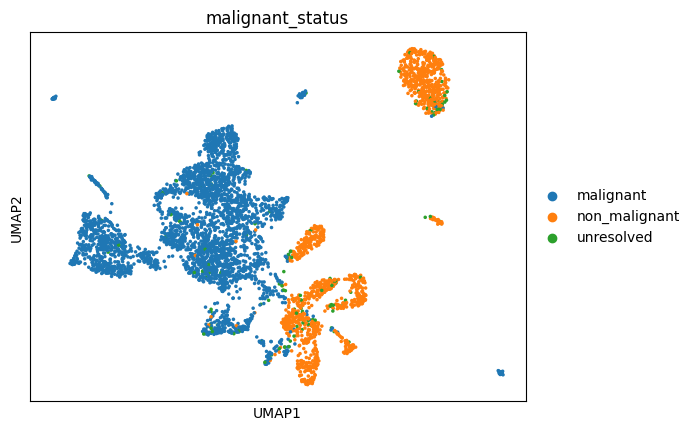

In [15]:
sc.pl.umap(adata, color="malignant_status")


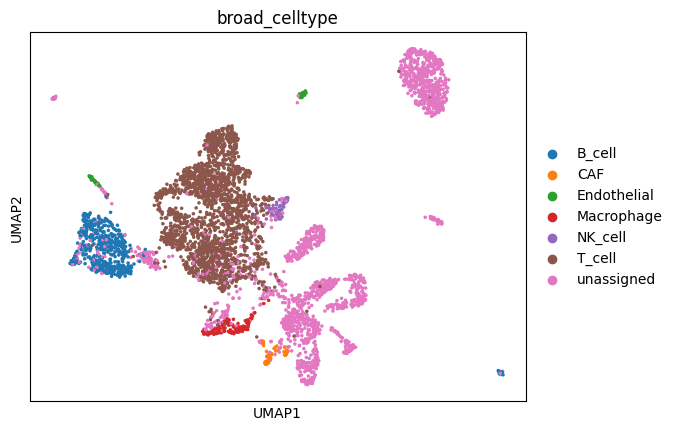

In [16]:
sc.pl.umap(adata, color="broad_celltype")

In [17]:
tcells = adata[adata.obs["broad_celltype"] == "T_cell"].copy()
print(tcells)

AnnData object with n_obs × n_vars = 2068 × 3000
    obs: 'patient_id', 'malignant_code', 'celltype_code', 'malignant_status', 'broad_celltype', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'malignant_status_colors', 'broad_celltype_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


In [18]:
exhaustion_genes = [
    "PDCD1",   # PD-1
    "LAG3",
    "HAVCR2",  # TIM3
    "TIGIT",
    "CTLA4",
    "TOX"
]

In [19]:
valid_genes = [g for g in exhaustion_genes if g in tcells.var_names]
print(valid_genes)

['PDCD1', 'LAG3', 'TIGIT', 'CTLA4', 'TOX']


In [20]:
sc.tl.score_genes(
    tcells,
    gene_list=valid_genes,
    score_name="exhaustion_score"
)

In [21]:
sc.pp.neighbors(tcells)
sc.tl.umap(tcells)

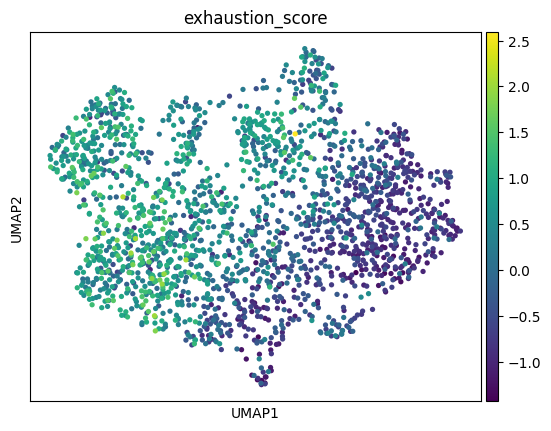

In [22]:
sc.pl.umap(
    tcells,
    color="exhaustion_score",
    cmap="viridis"
)

C:\Users\PC\AppData\Local\Temp\ipykernel_7796\1413092481.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(tcells, resolution=0.4, key_added="tcell_cluster")


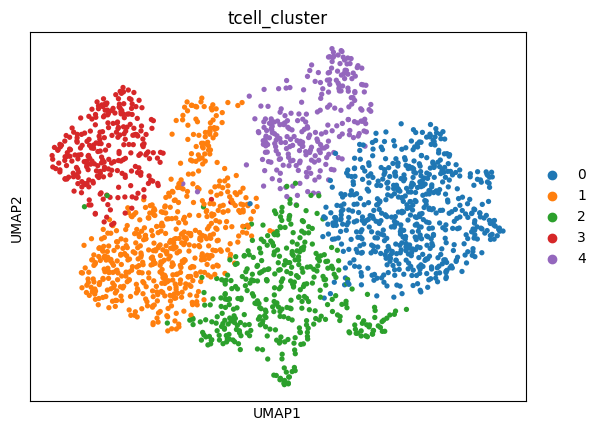

In [23]:
sc.tl.leiden(tcells, resolution=0.4, key_added="tcell_cluster")
sc.pl.umap(tcells, color="tcell_cluster")

C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scanpy\tools\_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scanpy\tools\_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scanpy\tools\_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scanpy\tools\_rank_genes

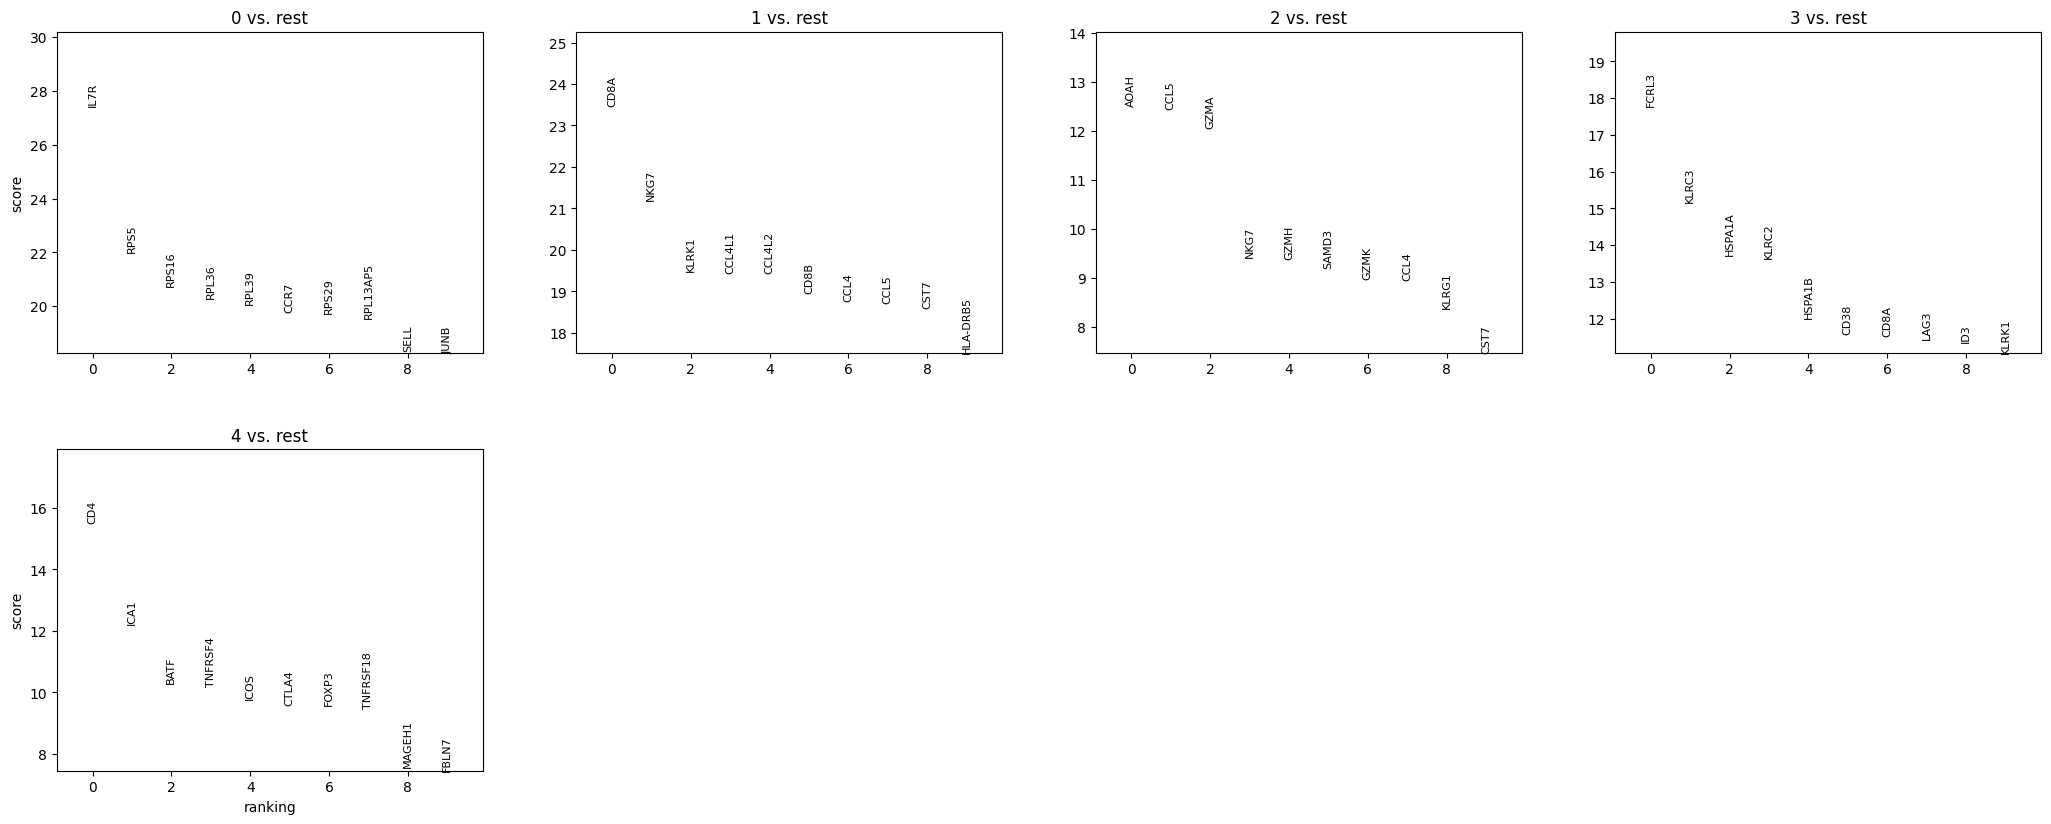

In [24]:
sc.tl.rank_genes_groups(
    tcells,
    "tcell_cluster",
    method="wilcoxon"
)

sc.pl.rank_genes_groups(
    tcells,
    n_genes=10,
    sharey=False
)

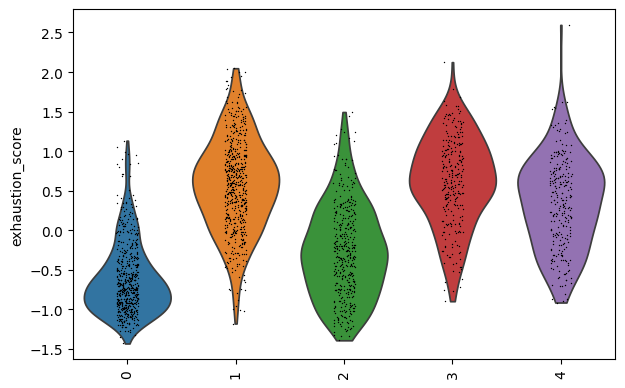

In [25]:
sc.pl.violin(
    tcells,
    keys="exhaustion_score",
    groupby="tcell_cluster",
    rotation=90
)

KeyError: 'Could not find key TCF7 in .var_names or .obs.columns.'

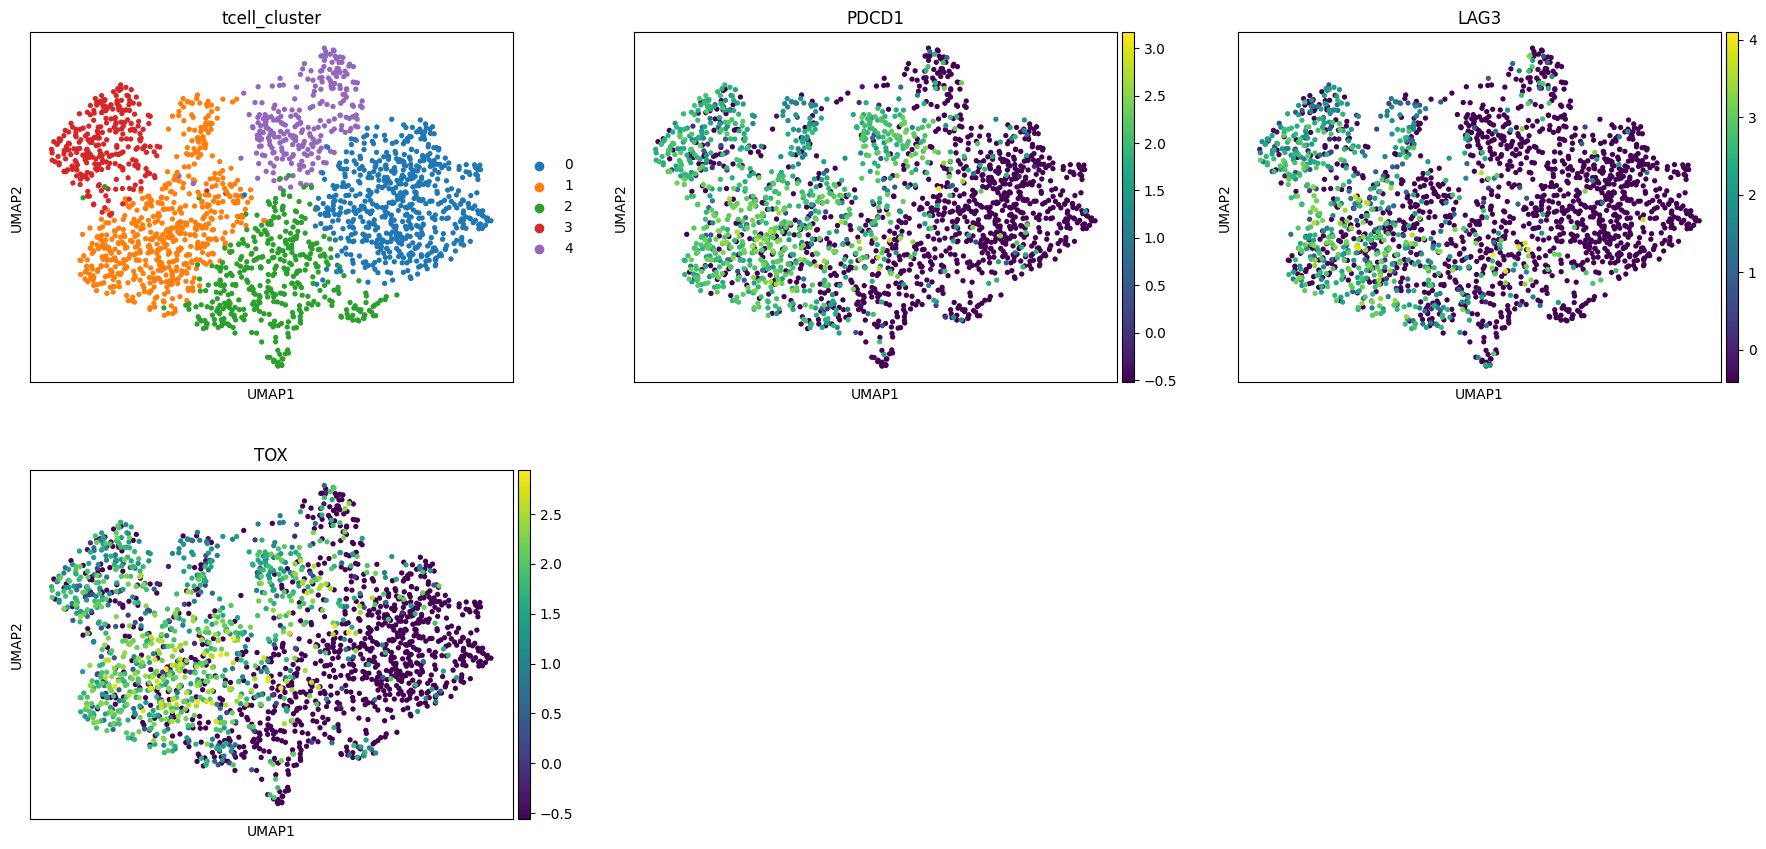

In [26]:
sc.pl.umap(
    tcells,
    color=["tcell_cluster", "PDCD1", "LAG3", "TOX", "TCF7", "GZMB"],
    ncols=3
)

In [27]:
tumor = adata[adata.obs["malignant_status"] == "malignant"].copy()
print(tumor)

AnnData object with n_obs × n_vars = 3256 × 3000
    obs: 'patient_id', 'malignant_code', 'celltype_code', 'malignant_status', 'broad_celltype', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'malignant_status_colors', 'broad_celltype_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


C:\Users\PC\AppData\Local\Temp\ipykernel_7796\2622227799.py:3: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(tumor, resolution=0.5, key_added="tumor_cluster")


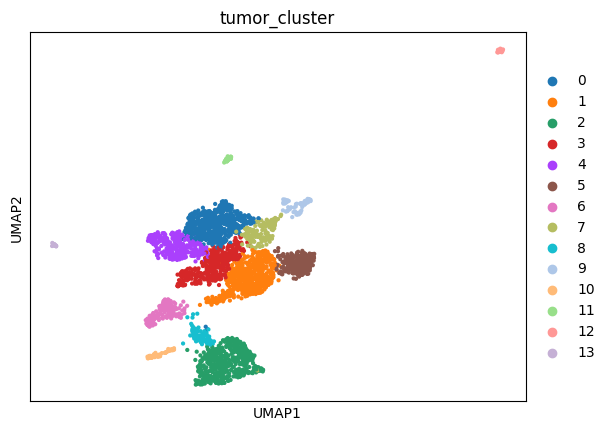

In [28]:
sc.pp.neighbors(tumor, n_neighbors=15, n_pcs=30)
sc.tl.umap(tumor)
sc.tl.leiden(tumor, resolution=0.5, key_added="tumor_cluster")

sc.pl.umap(tumor, color="tumor_cluster")

C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scanpy\tools\_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scanpy\tools\_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scanpy\tools\_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scanpy\tools\_rank_genes

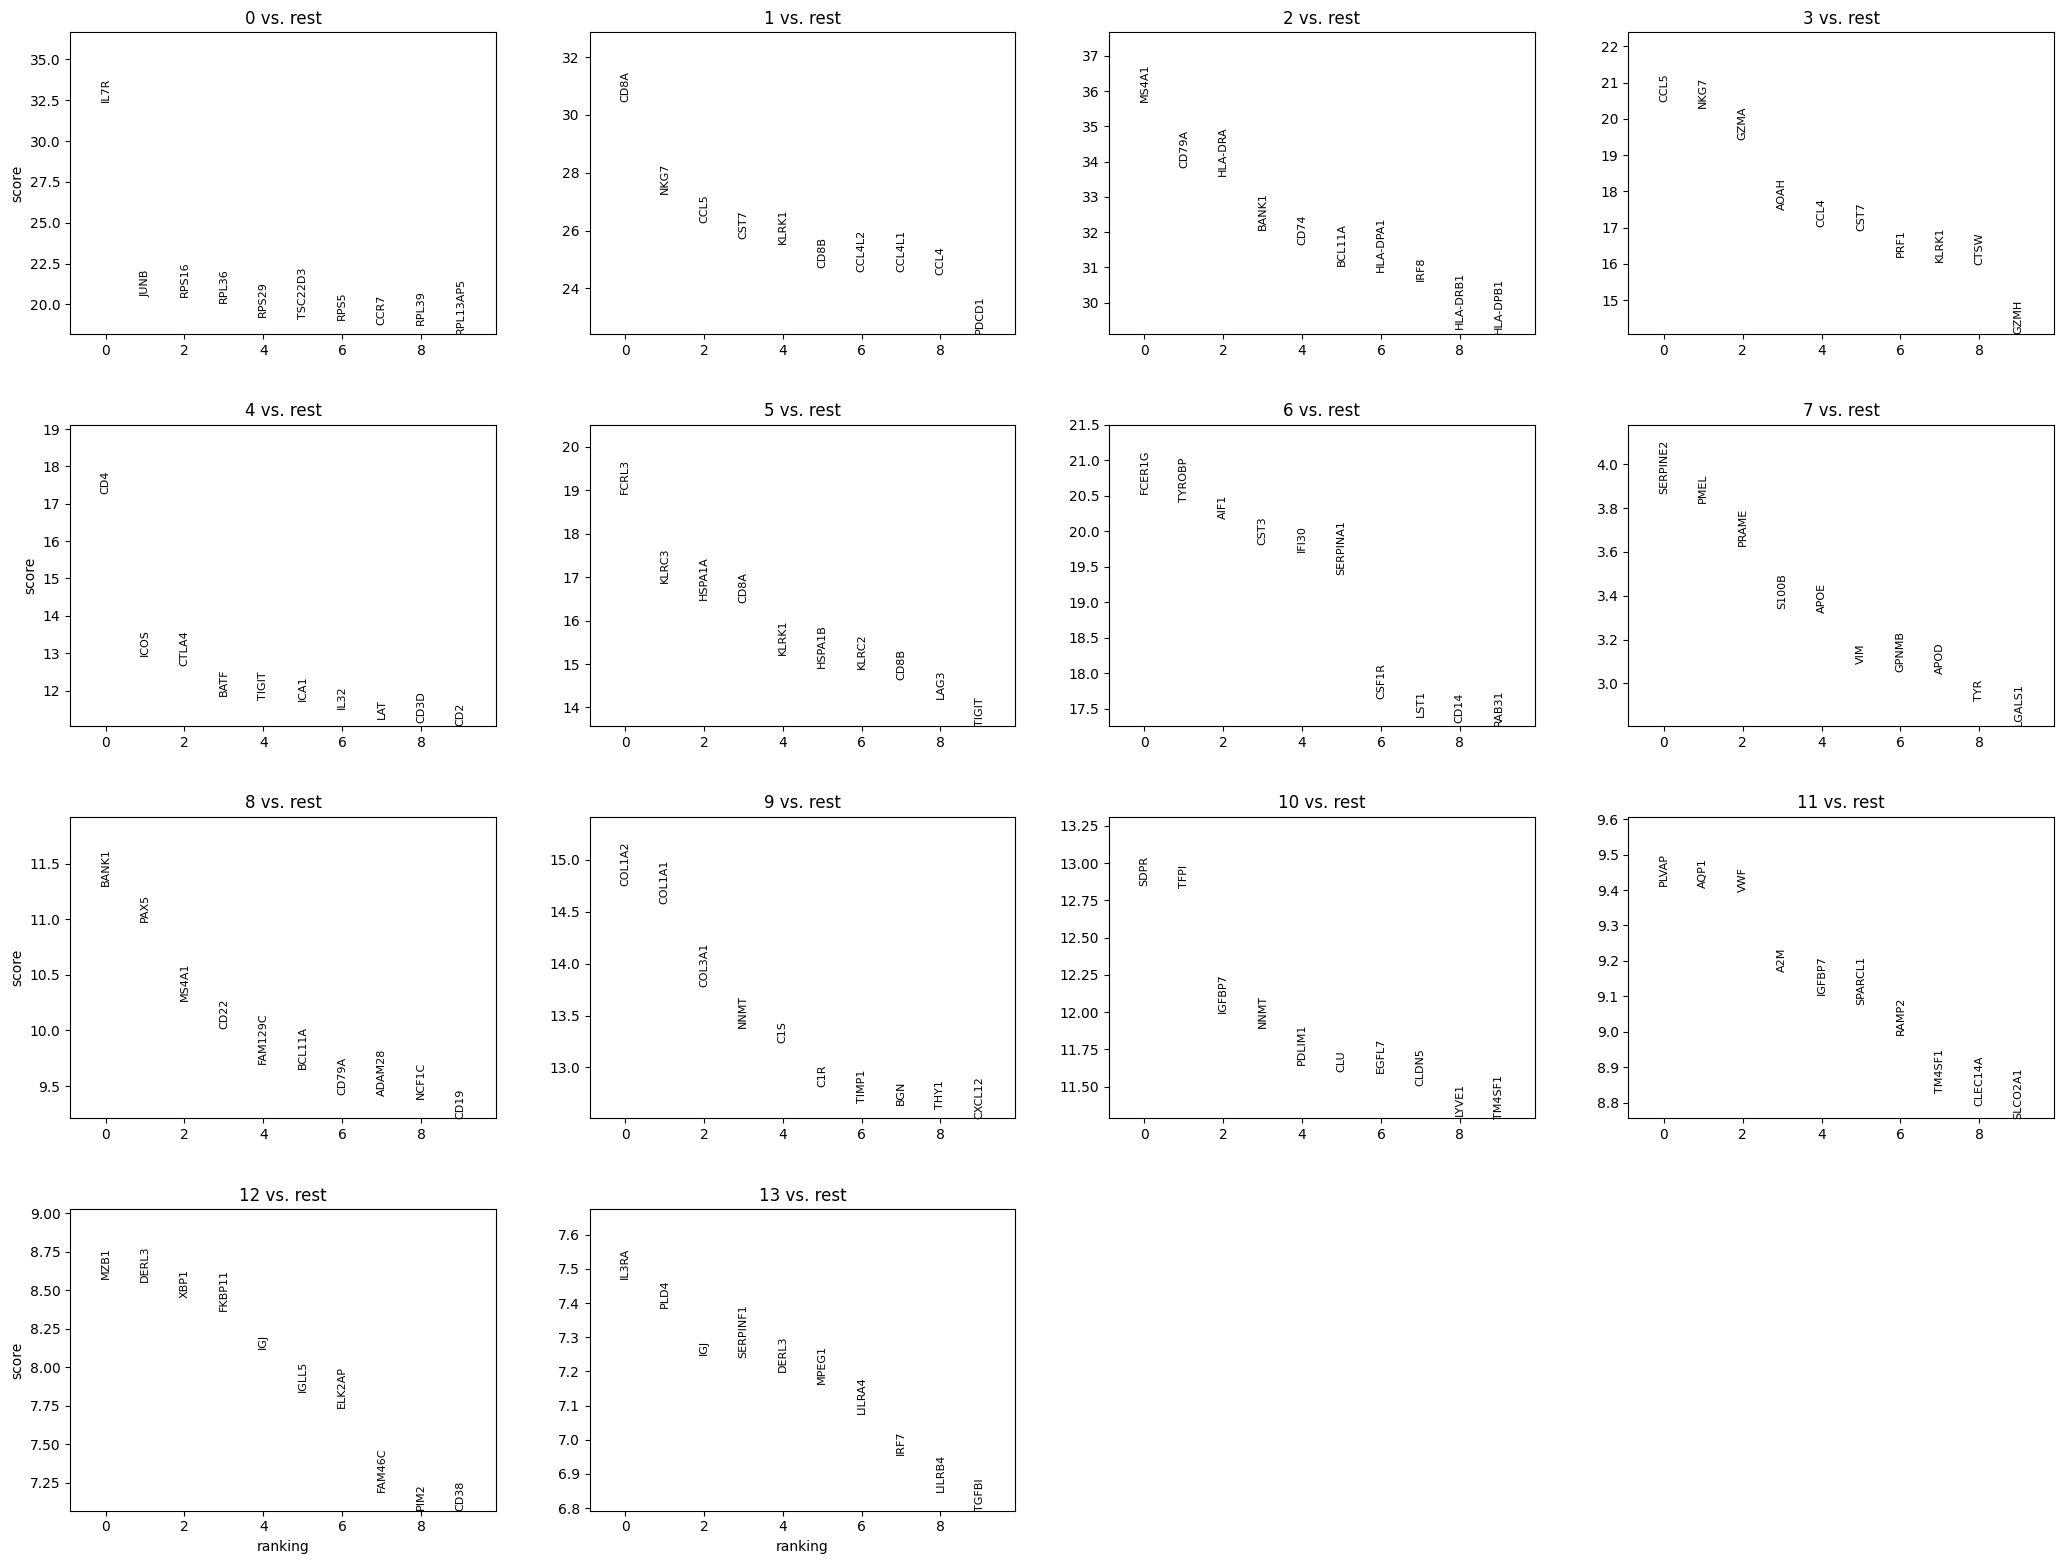

In [29]:
sc.tl.rank_genes_groups(
    tumor,
    "tumor_cluster",
    method="wilcoxon"
)

sc.pl.rank_genes_groups(
    tumor,
    n_genes=10,
    sharey=False
)

C:\Users\PC\AppData\Local\Temp\ipykernel_7796\126317605.py:3: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(tumor, resolution=0.5, key_added="tumor_cluster")


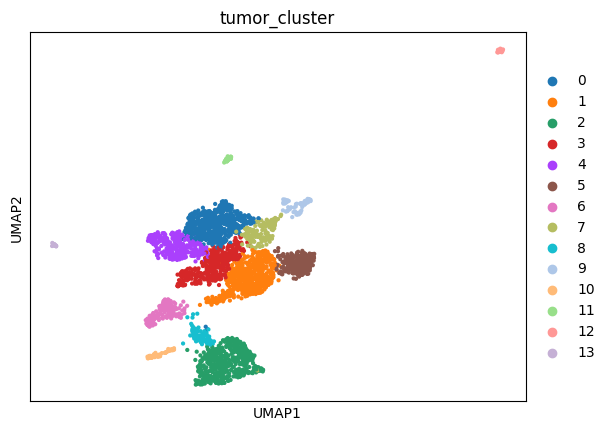

In [30]:
sc.pp.neighbors(tumor, n_neighbors=15, n_pcs=30)
sc.tl.umap(tumor)
sc.tl.leiden(tumor, resolution=0.5, key_added="tumor_cluster")

sc.pl.umap(tumor, color="tumor_cluster")


C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scanpy\tools\_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scanpy\tools\_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scanpy\tools\_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scanpy\tools\_rank_genes

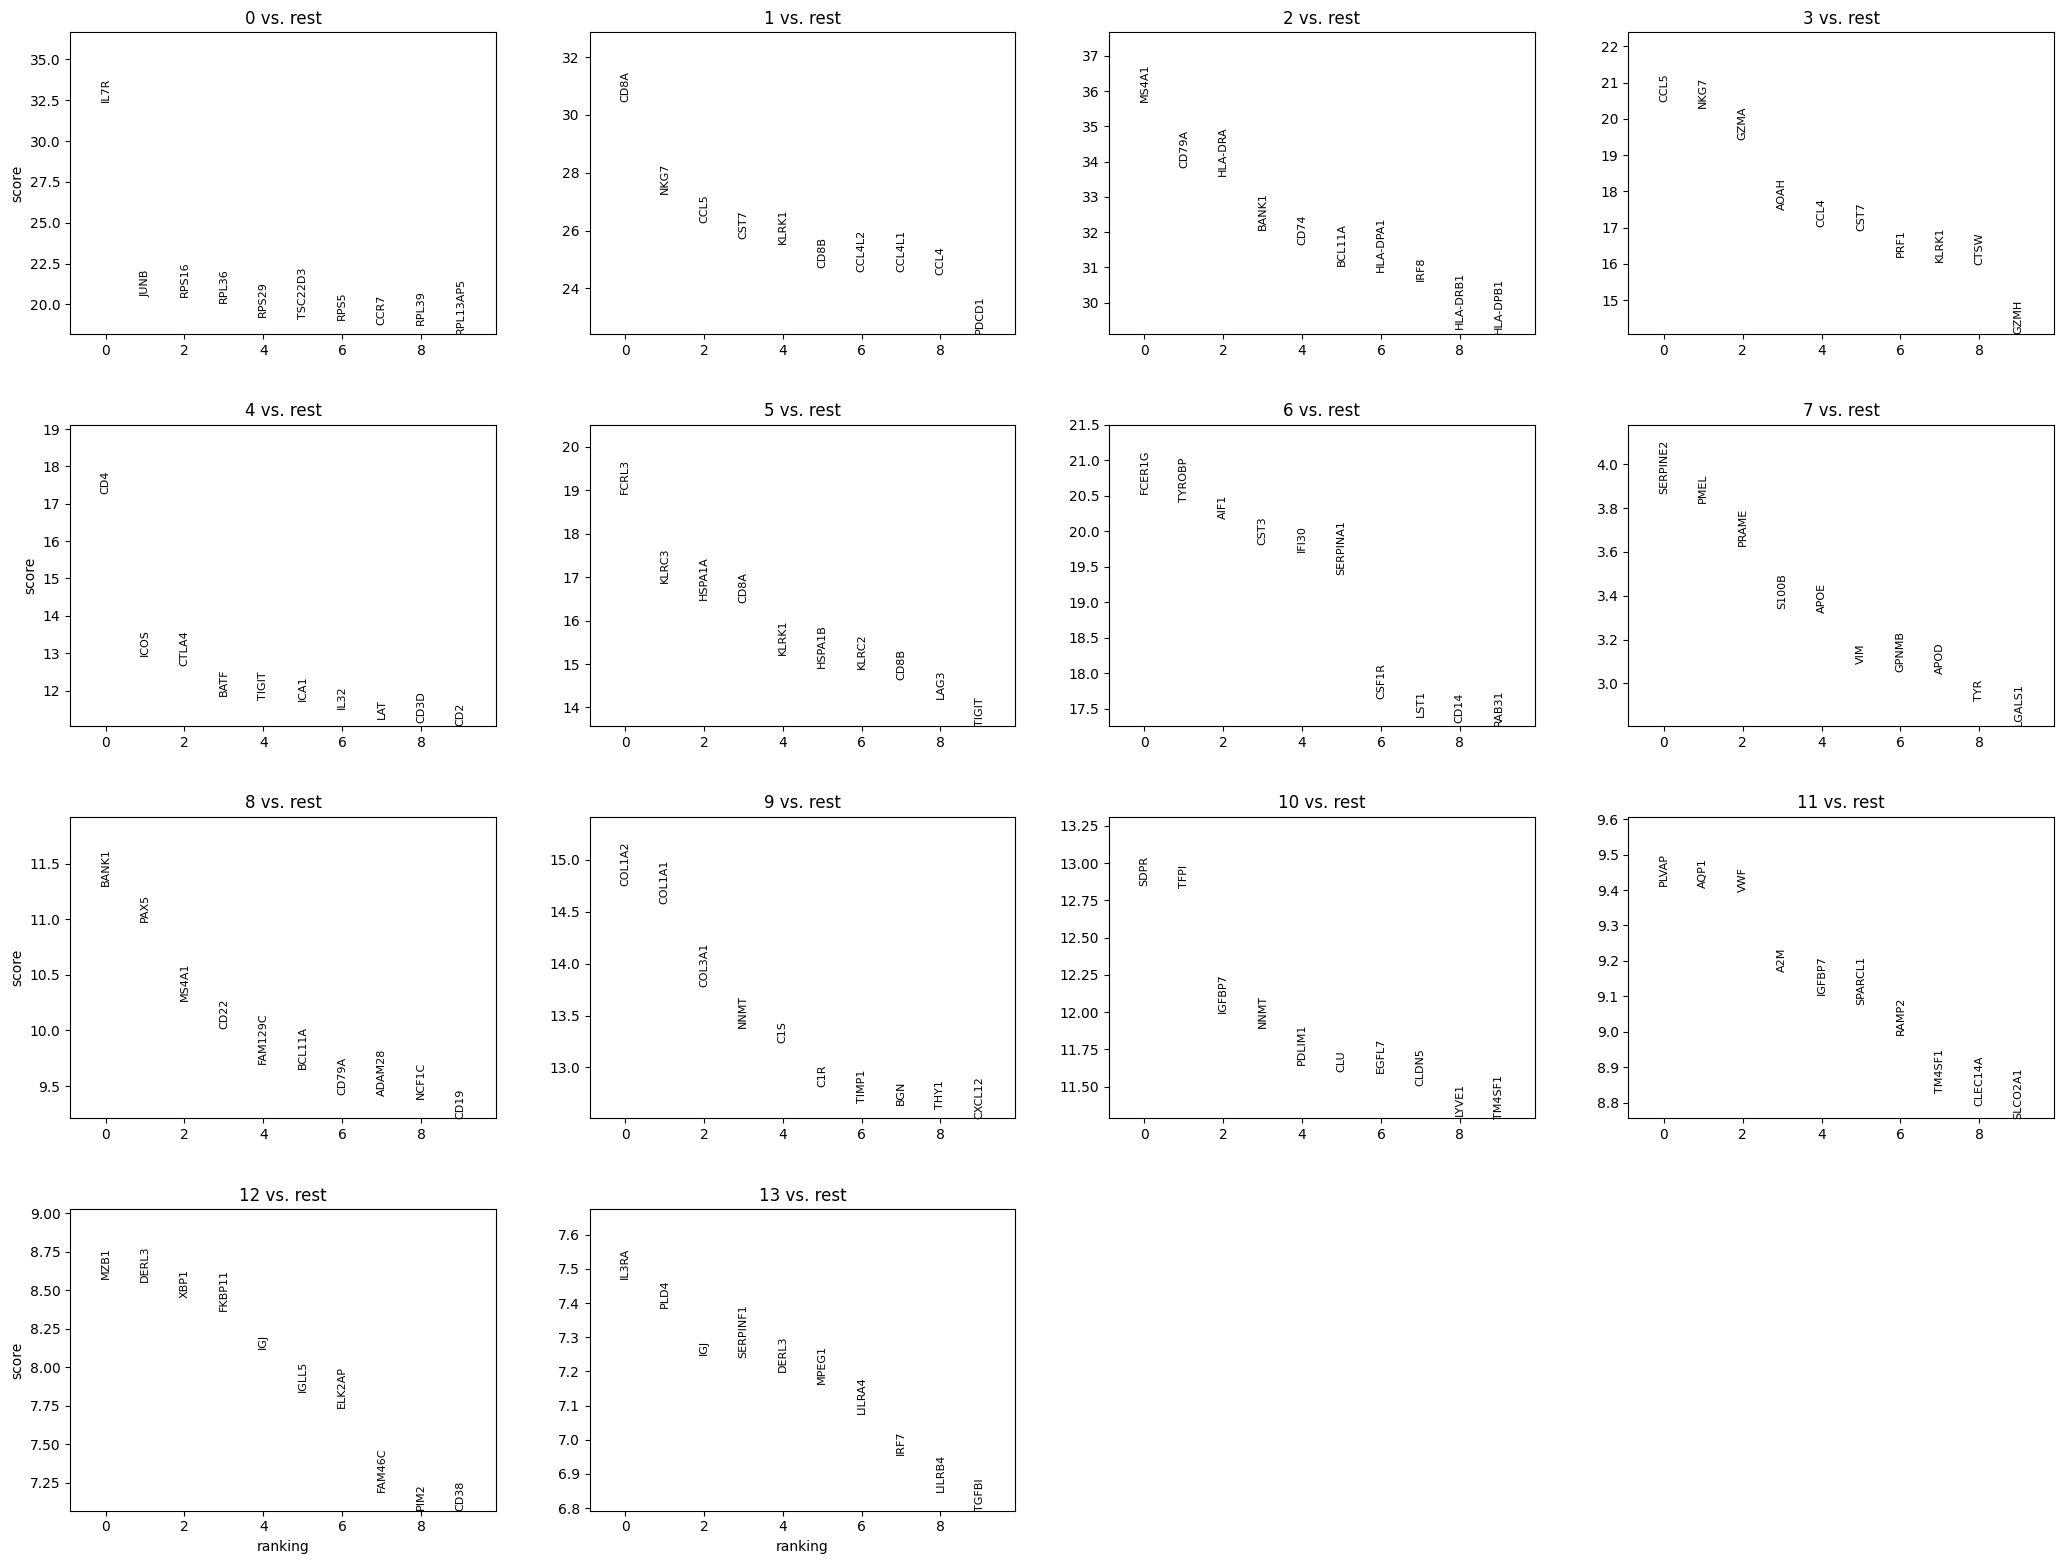

In [31]:
sc.tl.rank_genes_groups(
    tumor,
    "tumor_cluster",
    method="wilcoxon"
)

sc.pl.rank_genes_groups(
    tumor,
    n_genes=10,
    sharey=False
)

KeyError: 'Could not find key MLANA in .var_names or .obs.columns.'

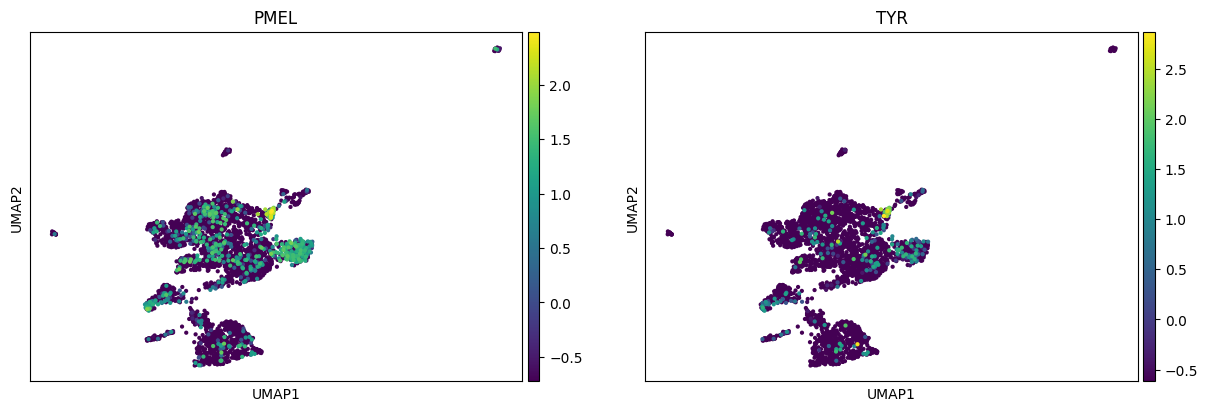

In [32]:
sc.pl.umap(
    tumor,
    color=["PMEL", "TYR", "MLANA", "MITF"],
    ncols=2
)

In [33]:
melanoma_genes = ["PMEL", "TYR", "MLANA", "MITF", "DCT"]
valid_melanoma = [g for g in melanoma_genes if g in tumor.var_names]
print(valid_melanoma)

['PMEL', 'TYR', 'DCT']


In [34]:
sc.tl.score_genes(
    tumor,
    gene_list=valid_melanoma,
    score_name="melanoma_score"
)

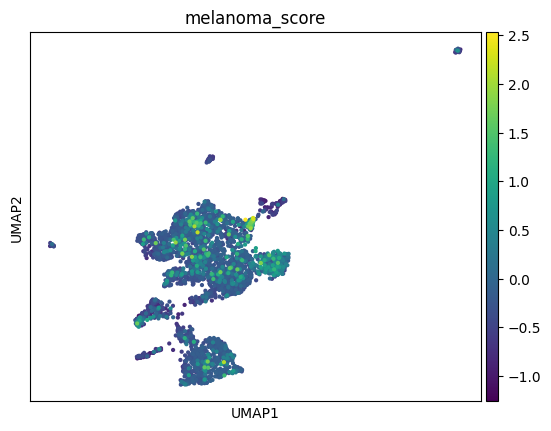

In [35]:
sc.pl.umap(
    tumor,
    color="melanoma_score",
    cmap="viridis"
)

In [37]:
tumor.obs["melanoma_score"].describe()

count    3256.000000
mean       -0.184760
std         0.419956
min        -1.258923
25%        -0.384258
50%        -0.251374
75%        -0.126759
max         2.533380
Name: melanoma_score, dtype: float64

In [38]:
threshold = 0.3

pure_tumor = tumor[tumor.obs["melanoma_score"] > threshold].copy()
print(pure_tumor)

AnnData object with n_obs × n_vars = 348 × 3000
    obs: 'patient_id', 'malignant_code', 'celltype_code', 'malignant_status', 'broad_celltype', 'leiden', 'tumor_cluster', 'melanoma_score'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'malignant_status_colors', 'broad_celltype_colors', 'tumor_cluster', 'tumor_cluster_colors', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


C:\Users\PC\AppData\Local\Temp\ipykernel_7796\674682998.py:3: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(pure_tumor, resolution=0.5, key_added="pure_cluster")


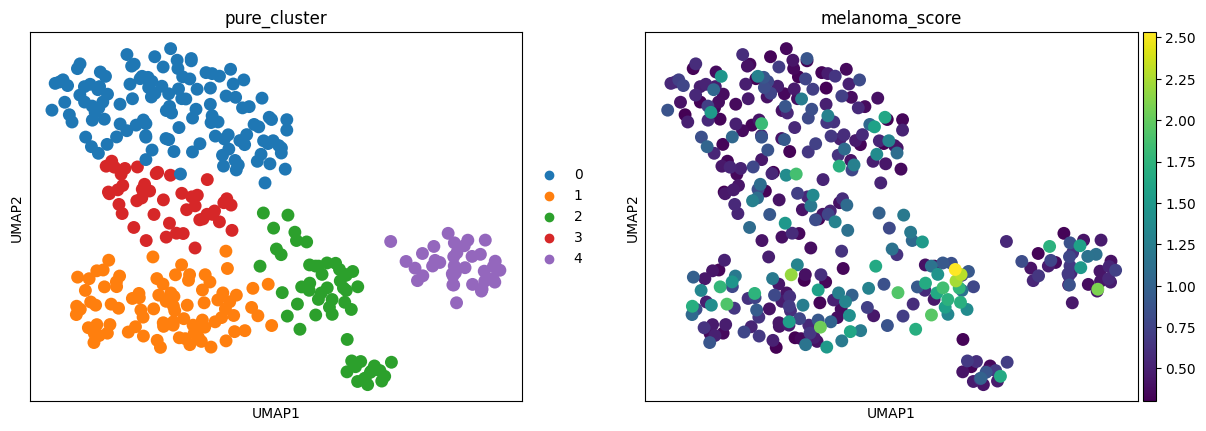

In [39]:
sc.pp.neighbors(pure_tumor)
sc.tl.umap(pure_tumor)
sc.tl.leiden(pure_tumor, resolution=0.5, key_added="pure_cluster")

sc.pl.umap(
    pure_tumor,
    color=["pure_cluster", "melanoma_score"],
    ncols=2
)

C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scanpy\tools\_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scanpy\tools\_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scanpy\tools\_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scanpy\tools\_rank_genes

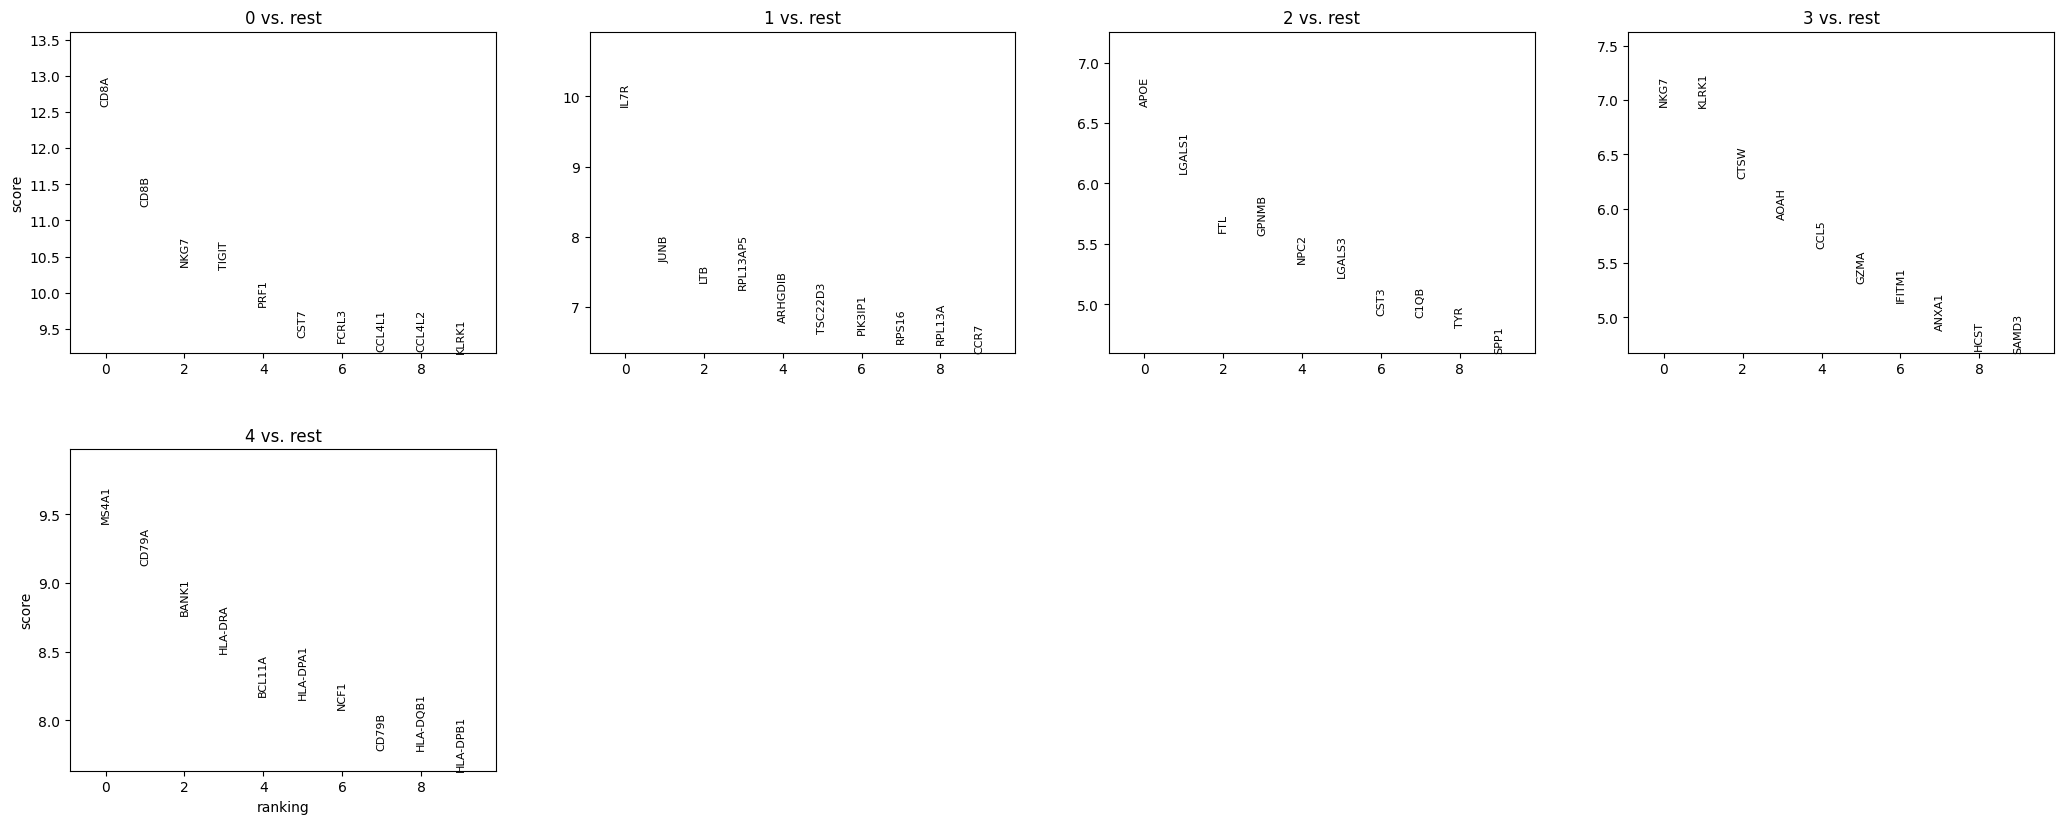

In [40]:
sc.tl.rank_genes_groups(
    pure_tumor,
    "pure_cluster",
    method="wilcoxon"
)

sc.pl.rank_genes_groups(
    pure_tumor,
    n_genes=10,
    sharey=False
)

In [41]:
sc.pl.umap(
    pure_tumor,
    color=[
        "MKI67", "TOP2A",      # proliferation
        "PMEL", "MLANA",      # melanocytic
        "AXL", "NGFR",        # invasive / dediff
        "JUN", "FOS"          # stress
    ],
    ncols=2
)

KeyError: 'Could not find key MKI67 in .var_names or .obs.columns.'

<Figure size 1455.6x1920 with 0 Axes>

In [42]:
tumor.obs["melanoma_score"].describe()

count    3256.000000
mean       -0.184760
std         0.419956
min        -1.258923
25%        -0.384258
50%        -0.251374
75%        -0.126759
max         2.533380
Name: melanoma_score, dtype: float64

In [43]:
threshold = 0.8
pure_tumor = tumor[tumor.obs["melanoma_score"] > threshold].copy()
print(pure_tumor)

AnnData object with n_obs × n_vars = 121 × 3000
    obs: 'patient_id', 'malignant_code', 'celltype_code', 'malignant_status', 'broad_celltype', 'leiden', 'tumor_cluster', 'melanoma_score'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'malignant_status_colors', 'broad_celltype_colors', 'tumor_cluster', 'tumor_cluster_colors', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


In [44]:
threshold = 1.0
pure_tumor = tumor[tumor.obs["melanoma_score"] > threshold].copy()
print(pure_tumor)


AnnData object with n_obs × n_vars = 87 × 3000
    obs: 'patient_id', 'malignant_code', 'celltype_code', 'malignant_status', 'broad_celltype', 'leiden', 'tumor_cluster', 'melanoma_score'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'malignant_status_colors', 'broad_celltype_colors', 'tumor_cluster', 'tumor_cluster_colors', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


C:\Users\PC\AppData\Local\Temp\ipykernel_7796\2935089383.py:3: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(pure_tumor, resolution=0.4, key_added="pure_cluster")


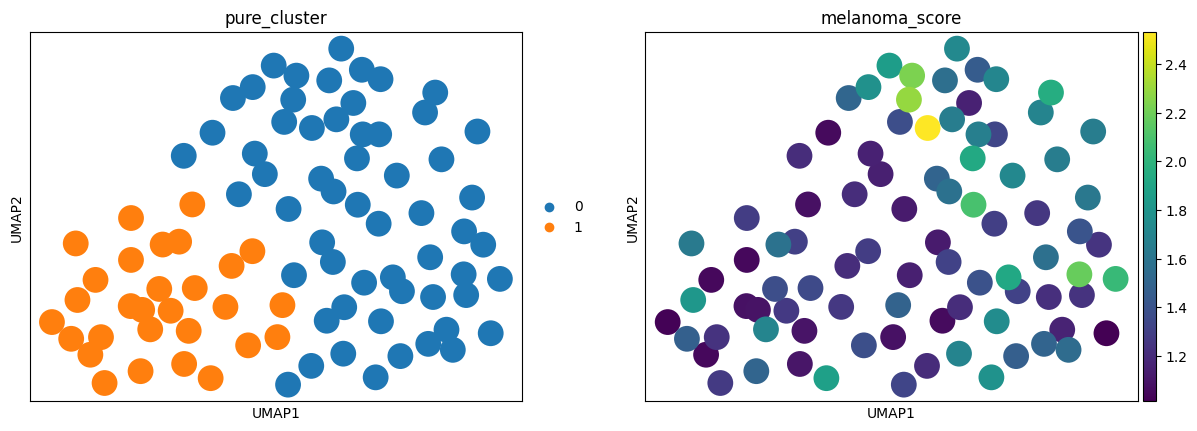

In [45]:
sc.pp.neighbors(pure_tumor)
sc.tl.umap(pure_tumor)
sc.tl.leiden(pure_tumor, resolution=0.4, key_added="pure_cluster")

sc.pl.umap(pure_tumor, color=["pure_cluster", "melanoma_score"], ncols=2)

KeyError: 'Could not find key MLANA in .var_names or .obs.columns.'

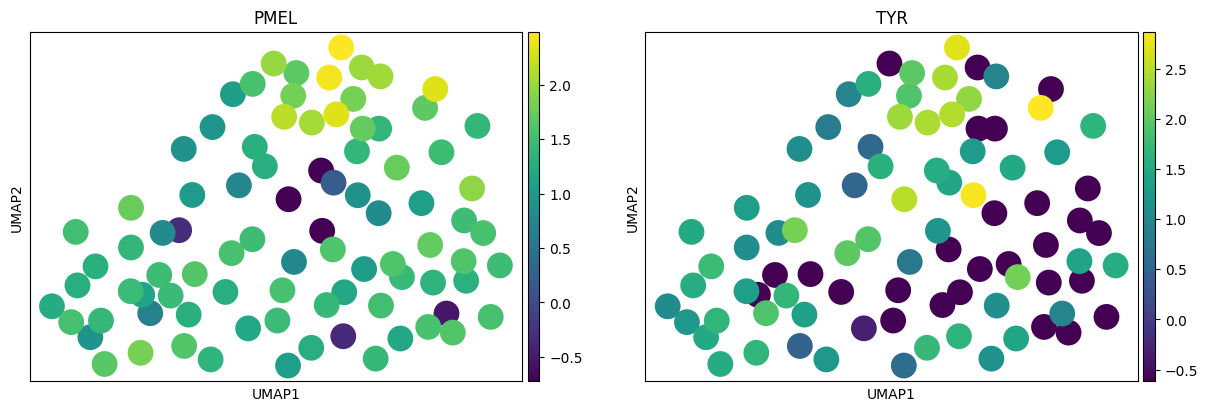

In [46]:
sc.pl.umap(
    pure_tumor,
    color=["PMEL", "TYR", "MLANA", "MITF"],
    ncols=2
)

C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scanpy\tools\_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scanpy\tools\_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


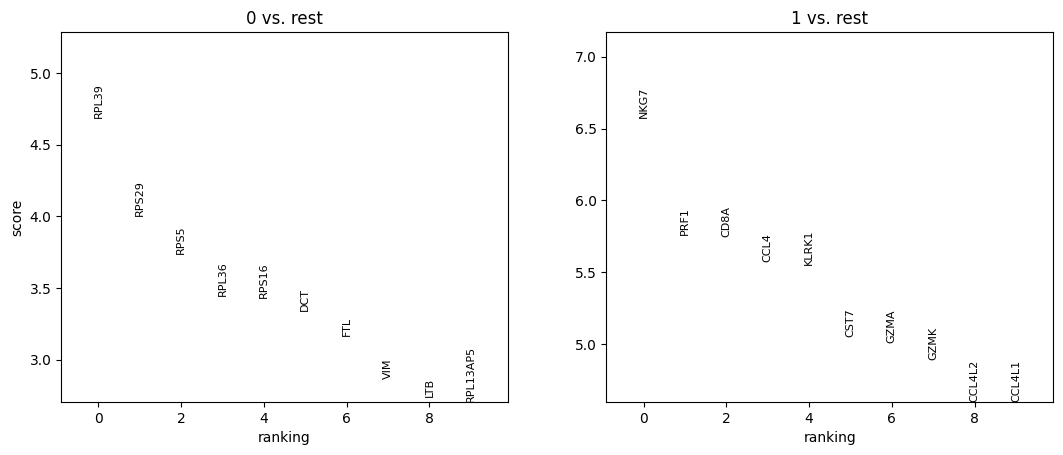

In [47]:
sc.tl.rank_genes_groups(pure_tumor, "pure_cluster", method="wilcoxon")
sc.pl.rank_genes_groups(pure_tumor, n_genes=10, sharey=False)

In [48]:
final_tumor = pure_tumor[pure_tumor.obs["pure_cluster"] == "0"].copy()
print(final_tumor)

AnnData object with n_obs × n_vars = 58 × 3000
    obs: 'patient_id', 'malignant_code', 'celltype_code', 'malignant_status', 'broad_celltype', 'leiden', 'tumor_cluster', 'melanoma_score', 'pure_cluster'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'malignant_status_colors', 'broad_celltype_colors', 'tumor_cluster', 'tumor_cluster_colors', 'rank_genes_groups', 'pure_cluster', 'pure_cluster_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


KeyError: 'Could not find key MLANA in .var_names or .obs.columns.'

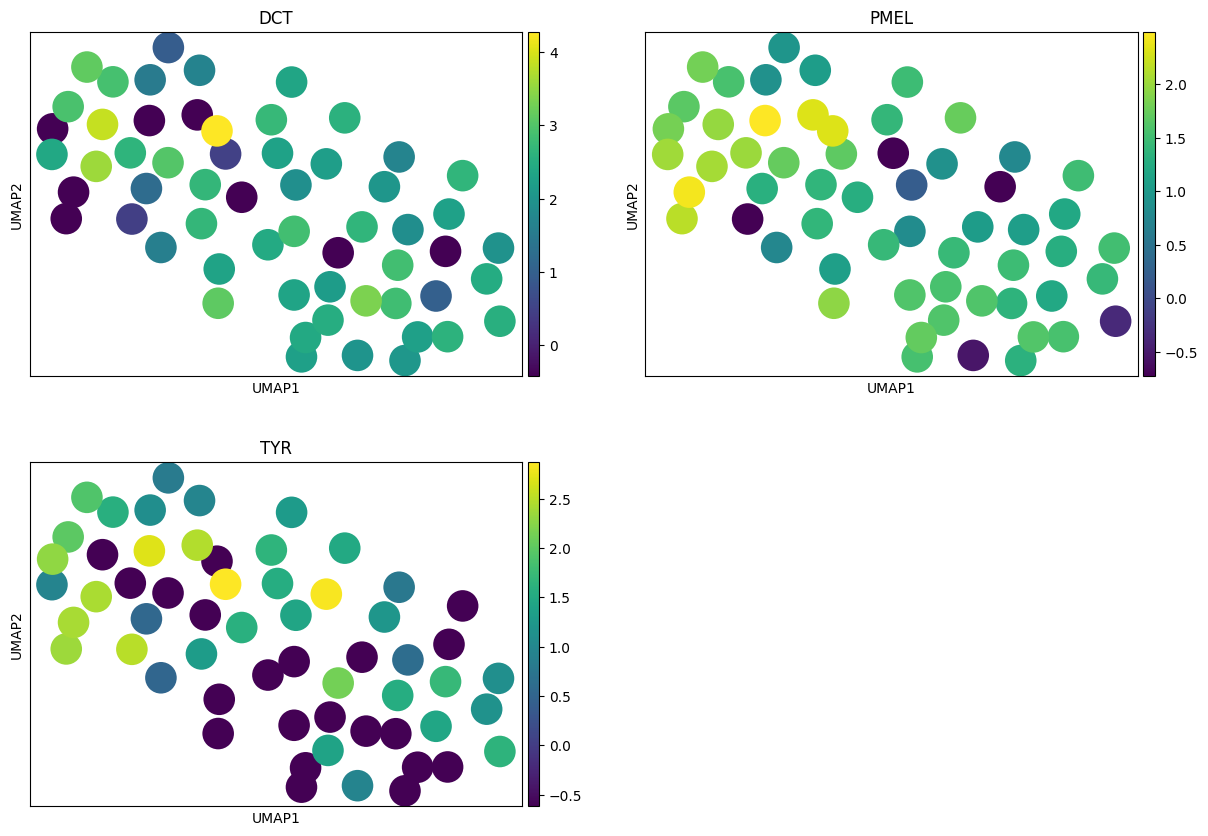

In [49]:
sc.pp.neighbors(final_tumor)
sc.tl.umap(final_tumor)

sc.pl.umap(
    final_tumor,
    color=["DCT", "PMEL", "TYR", "MLANA", "MITF"],
    ncols=2
)

In [50]:
[g for g in ["DCT", "PMEL", "TYR", "MLANA", "MITF"] if g in final_tumor.var_names]

['DCT', 'PMEL', 'TYR']

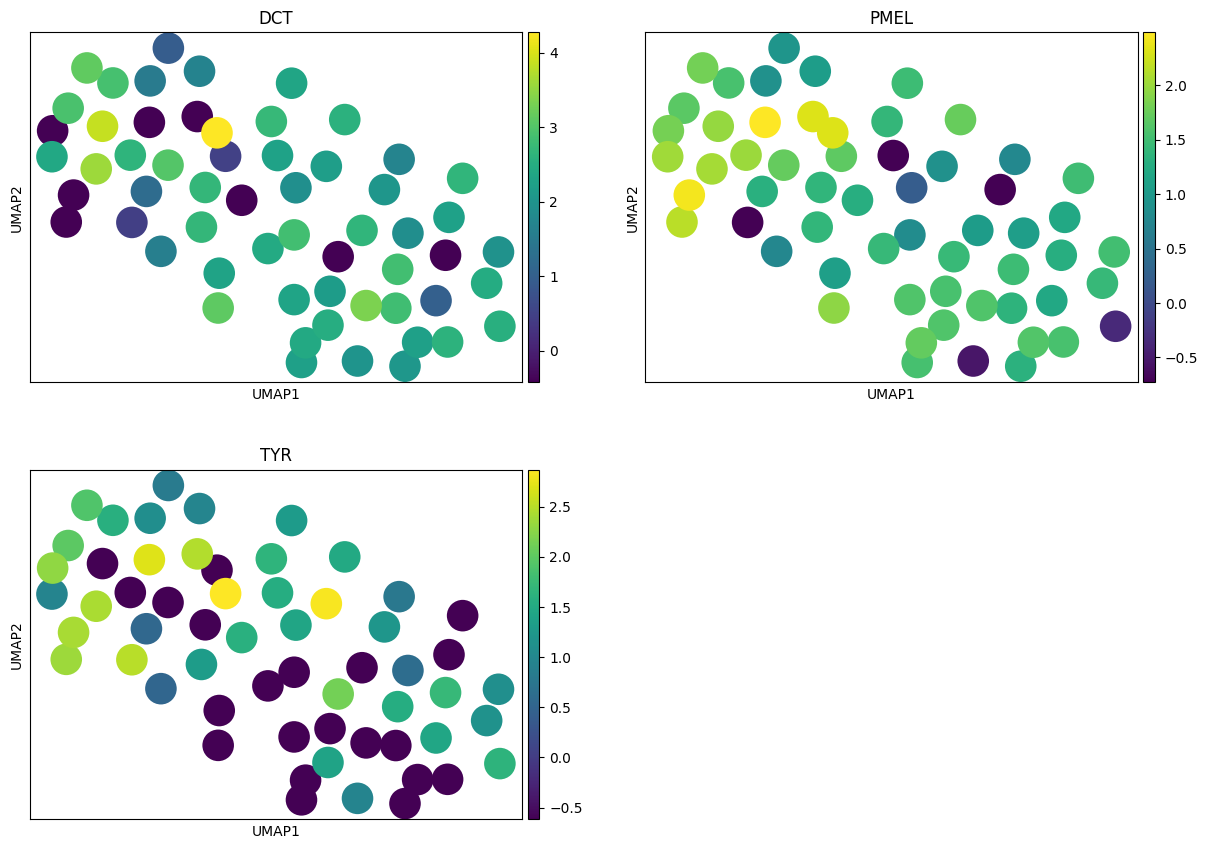

In [51]:
sc.pl.umap(
    final_tumor,
    color=["DCT", "PMEL", "TYR"],
    ncols=2
)

C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\fast_array_utils\stats\_mean.py:29: RuntimeWarning: invalid value encountered in divide
  return total / n  # type: ignore[no-any-return]
C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scanpy\tools\_rank_genes_groups.py:379: RuntimeWarning: invalid value encountered in divide
  scores[group_index, :] = (
C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scanpy\plotting\_tools\__init__.py:465: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axs[-1].set_ylim(ymin, ymax)


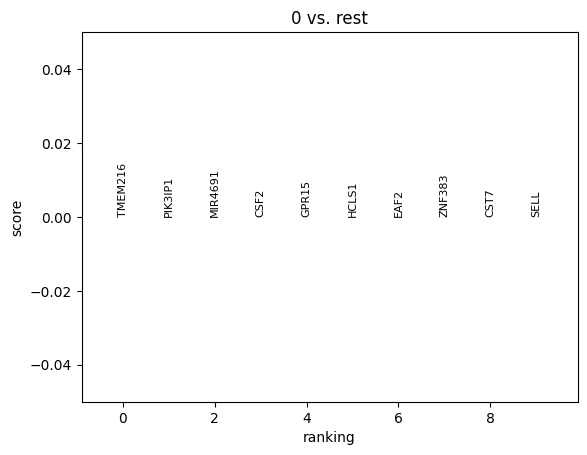

In [53]:
sc.tl.rank_genes_groups(
    final_tumor,
    "pure_cluster",
    method="wilcoxon"
)

sc.pl.rank_genes_groups(
    final_tumor,
    n_genes=10,
    sharey=False
)

In [54]:
valid_program_genes = [
    g for g in ["MKI67", "TOP2A", "PCNA", "DCT", "PMEL", "TYR", "MITF", "JUN", "FOS", "VIM"]
    if g in final_tumor.var_names
]

print(valid_program_genes)

['PCNA', 'DCT', 'PMEL', 'TYR', 'FOS', 'VIM']


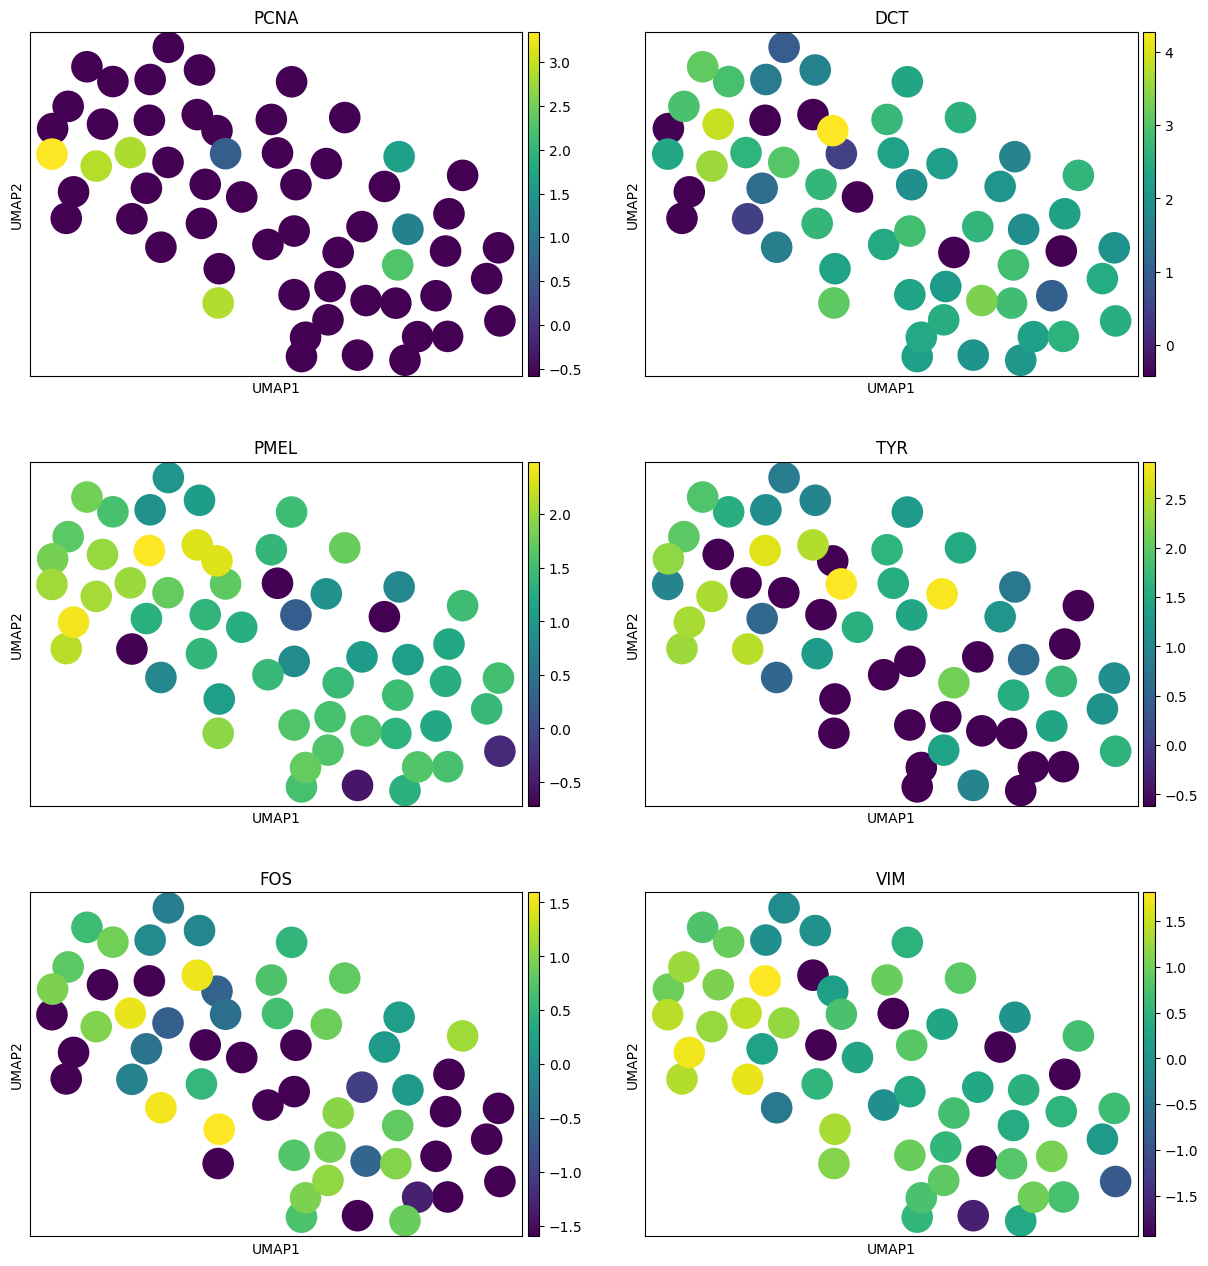

In [55]:
sc.pl.umap(
    final_tumor,
    color=valid_program_genes,
    ncols=2
)

C:\Users\PC\AppData\Local\Temp\ipykernel_7796\3199055230.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(adata, color="malignant_status", save="_malignant_status.png")


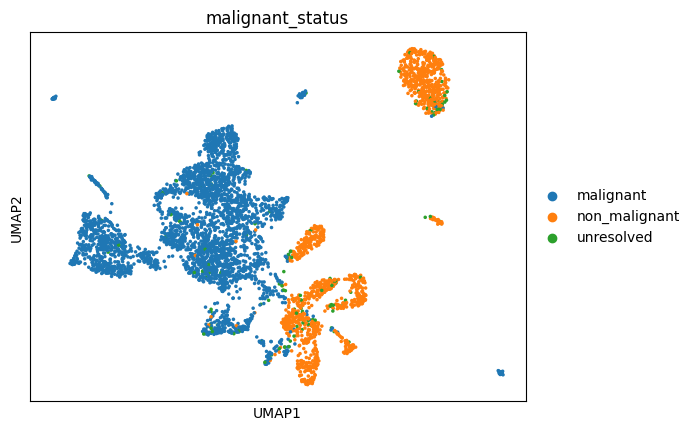

In [56]:
sc.pl.umap(adata, color="malignant_status", save="_malignant_status.png")

C:\Users\PC\AppData\Local\Temp\ipykernel_7796\804406968.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(tcells, color="exhaustion_score", save="_exhaustion.png")


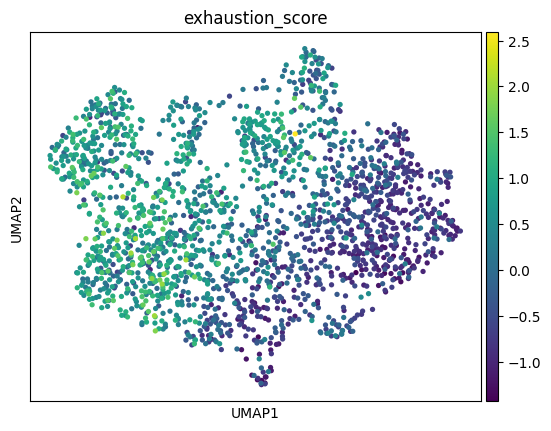

In [57]:
sc.pl.umap(tcells, color="exhaustion_score", save="_exhaustion.png")

C:\Users\PC\AppData\Local\Temp\ipykernel_7796\3696516017.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(tumor, color="tumor_cluster", save="_tumor_clusters.png")


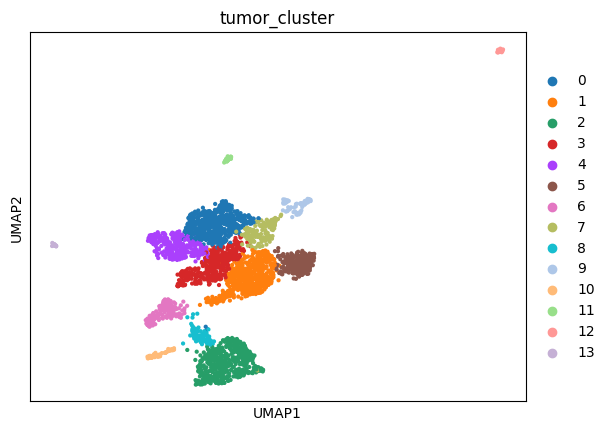

In [58]:
sc.pl.umap(tumor, color="tumor_cluster", save="_tumor_clusters.png")

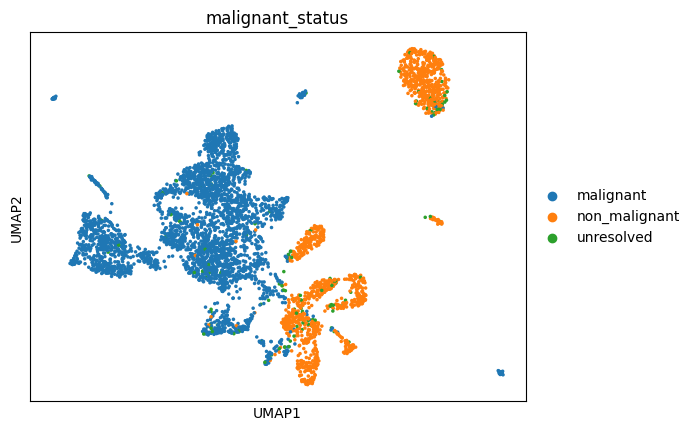

In [59]:
import matplotlib.pyplot as plt
sc.pl.umap(adata, color="malignant_status", show=False)
plt.savefig("figures/malignant_status.png", dpi=300, bbox_inches="tight")
plt.show()